google earth engine API

Import and authenticate google earth engine API

In [354]:
import ee
ee.Authenticate()
ee.Initialize()

Determine ROI of lake eerie.

Some interesting information:
It is the fourth-largest lake by surface area of the five Great Lakes in North America and the eleventh-largest globally. It is the southernmost, shallowest, and smallest by volume of the Great Lakes and also has the shortest average water residence time. At its deepest point, Lake Erie is 210 feet (64 m) deep, making it the only Great Lake whose deepest point is above sea level.

In [355]:
# define point and buffer on lake eerie - point found using the gee map
lon, lat = -81.2, 42.2
lakeeerie = ee.Geometry.Point([lon, lat]) 
buffer = lakeeerie.buffer(200)           # 200 m radius
bbox = buffer.bounds()               # ROI rectangle used for statistics

# Scale in meters for reduceRegion (Landsat ~30m) https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LT04_C02_T1_L2#bands
SCALE = 30
MAXPIX = 1e9

# Date range
start = '1982-07-16' # launch of Landsat 4
end = '2025-11-02' # last date of collection Landsat 9

Apply scaling factors to convert from F to K, values found using https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LT05_C02_T1_L2#description under apply scale factors section. These values were the same for Landsat 4-9.

In [356]:
def apply_scale_factors(image):
    """
    Convert surface temperature bands to Kelvin
    """
    # Apply scale and offset 
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0).rename('surface_temp_k')
    
    return image.addBands(thermal, overwrite=True)

Bit 0: Fill<br>Bit 1: Dilated Cloud<br>Bit 2: Unused<br>Bit 3: Cloud<br>Bit 4: Cloud Shadow<br>Bit 5: Snow<br>Bit 6: Clear<br>
> 0: Cloud or Dilated Cloud bits are set  <br>
> 1: Cloud and Dilated Cloud bits are not set <br>
Bit 7: Water
<br>Bits 8-9: Cloud Confidence<br>
> 0: None<br>
> 1: Low<br>
> 2: Medium<br>
> 3: High<br>
<br>Bits 10-11: Cloud Shadow Confidence<br>
> 0: None<br>
> 1: Low<br>
> 2: Medium<br>
> 3: High<br>
<br>Bits 12-13: Snow/Ice Confidence<br>
> 0: None<br>
> 1: Low<br>
> 2: Medium<br>
> 3: High<br>
<br>Bits 14-15: Cirrus Confidence<br>
> 0: None<br>
> 1: Low<br>
> 2: Medium<br>
> 3: High<br>

The following defintion masks out pixels with cloud, cloud shadow, and snow for values that also have medium to high confidence in cloud, cloud shadow, snow, and/or cirrus cloud. 

QA_Pixel consists of a string of bits per pixel, this scheme needs to be unencoded using the key found at https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LE07_C02_T1_L2#bands under bitmask for QA pixel. The above text block details this scheme.


In [357]:
def cloud_bitmask(image):
    """
    Mask out approproate bits:
        for single bit flags, grab the mask and find if value exists
        for multi-bit flags, use bitwiseAnd(3 << #) to mask 2 digits,
        and use rightShift(#) to moves bits back to integer range (0–3)
    """
    # select pixel mask
    qa = image.select('QA_PIXEL')
    
    # Single-bit flags
    cloud = qa.bitwiseAnd(1 << 3).neq(0) # neq comapres value to 0, returns true if value not 0.
    cloud_shadow = qa.bitwiseAnd(1 << 4).neq(0)
    snow = qa.bitwiseAnd(1 << 5).neq(0)

    # Multi-bit confidence fields (2 bits each)
    cloud_conf = qa.bitwiseAnd(3 << 8).rightShift(8)         # bits 8–9
    shadow_conf = qa.bitwiseAnd(3 << 10).rightShift(10)      # bits 10–11
    snow_conf = qa.bitwiseAnd(3 << 12).rightShift(12)        # bits 12–13
    cirrus_conf = qa.bitwiseAnd(3 << 14).rightShift(14)      # bits 14–15

    # Build mask - identify cloudy pixels AND if medium/high confidence
    cloudy = (
        cloud
        .Or(cloud_shadow)
        .Or(snow)
        .And(cloud_conf.gte(2))      # medium (2) or high (3)
        .And(shadow_conf.gte(2))
        .And(snow_conf.gte(2))
        .And(cirrus_conf.gte(2))
    )
    
    # Invert mask to get usable data
    clear = cloudy.Not()

    # return non-cloudy image pixels
    return image.updateMask(clear)

Calculate the average of a band for each image in an ImageCollection within the selected patch.
THe followin fucntion uses the map() function to apply reduceRegion() to each image in the collection.

In [358]:
def process_image(image):
    """
    Apply scaling and cloud bitmasking.
    Compute average surface temperature (median) of patch.
    """
    scaled = apply_scale_factors(image)
    masked = cloud_bitmask(scaled)

    # Count valid pixels in bbox (after mask). If zero, skip the scene.
    count_dict = masked.select('surface_temp_k').reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=bbox,
        scale=SCALE,
        maxPixels=MAXPIX
    )
    count = ee.Number(count_dict.get('surface_temp_k'))

    # Compute median only if count > 0
    median_dict = masked.select('surface_temp_k').reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bbox,
        scale=SCALE,
        maxPixels=MAXPIX
    )
    median_val = median_dict.get('surface_temp_k')

    # If there are valid pixels, attach median as property 'average_temp' and keep image; otherwise return None
    return ee.Image(ee.Algorithms.If(
        count.gt(0),
        image.set('average_temp', median_val),
        image.set('average_temp', None)   # preserves type (image)
    ))

In [359]:
# Convert image to Feature (for table export)
def image_to_feature(image):
    # Ensure image is an ee.Image
    img = ee.Image(image)
    date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')
    avg_temp = img.get('average_temp')
    sat = image.get("SPACECRAFT_ID") # grab satellite ID
    return ee.Feature(None, {
        'date': date,
        'average_surface_temp': avg_temp,
        'satellite': sat
    })

In [360]:
# Build and export a collection per Landsat mission
def export_csv(collection, name):
    # Filter by bbox and date range already done upstream--apply processing.
    processed = collection.map(process_image)
    # Remove null results (fully cloudy scenes)
    processed = processed.filter(ee.Filter.notNull(['average_temp']))
    # Create FeatureCollection of metadata
    metadata_fc = processed.map(image_to_feature)

    # Export to Drive 
    task = ee.batch.Export.table.toDrive(
        collection=metadata_fc,
        description=f'{name}_surface_temp',
        fileNamePrefix=name,
        folder='earthengine',
        fileFormat='CSV'
    )
    task.start()

In [361]:
# Prepare collections (filter by bbox and date)
L4 = ee.ImageCollection("LANDSAT/LT04/C02/T1_L2").filterBounds(bbox).filterDate(start, end)
L5 = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2").filterBounds(bbox).filterDate(start, end)
L7 = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2").filterBounds(bbox).filterDate(start, end)
L8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(bbox).filterDate(start, end)
L9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(bbox).filterDate(start, end)

merged_collection = ee.ImageCollection(
    L4
    .merge(L5)
    .merge(L7)
    .merge(L8)
    .merge(L9)
)

# Run exports for each satellite (short names)
export_csv(merged_collection, "lakeeerie_-81.2N.42.2W")

/Users/sutku/Scripts/ML/gee
FOUND FILES: ['csv/lakeeerie_-81.82N.41.69W.csv', 'csv/lakeeerie_-81.2N.42.2W.csv']


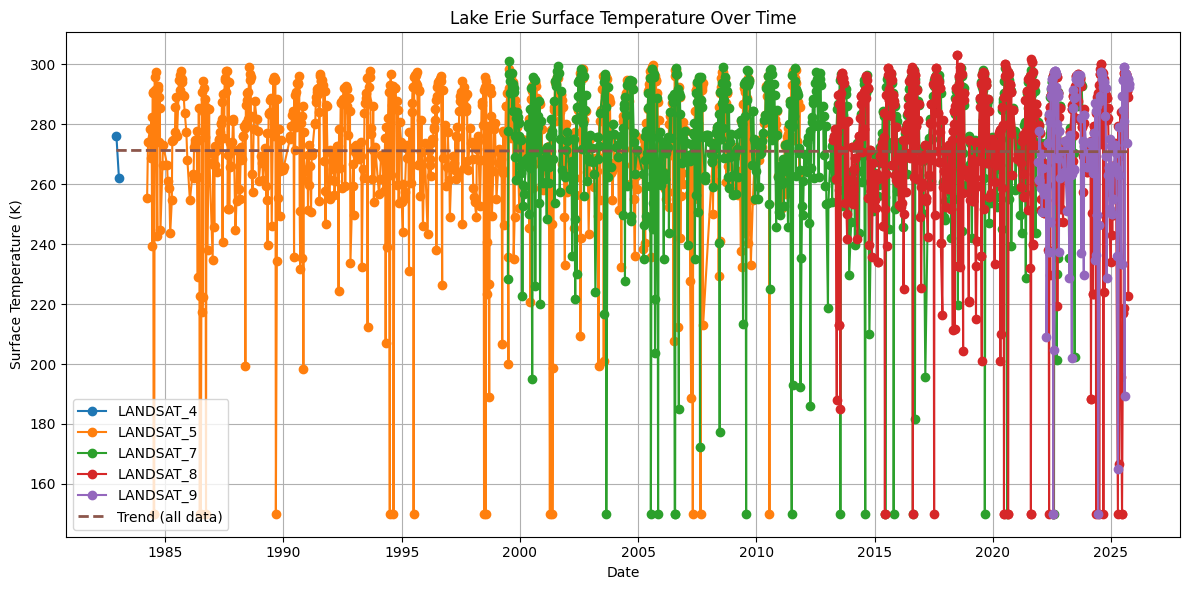

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np 

print(os.getcwd())
# Grab all CSV files
csv_file = glob.glob("csv/*.csv")
print("FOUND FILES:", csv_file)  # error check
# Load the CSV
df = pd.read_csv("csv/lakeeerie_-81.2N.42.2W.csv") # This file was saved to my google drive then placed in my directory.
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])
# Sort by date 
df = df.sort_values("date")

# Compute trend across the entire dataset
x = df["date"].map(lambda d: d.toordinal())
y = df["average_surface_temp"]
m, b = np.polyfit(x, y, 1)  
df["trend"] = m * x + b

# Plot each satellite separately
plt.figure(figsize=(12, 6))
for sat, group in df.groupby("satellite"):
    plt.plot(group["date"], group["average_surface_temp"], marker='o', linestyle='-', label=sat)

# Plot the trendline 
plt.plot(df["date"], df["trend"], linestyle='--', linewidth=2, label="Trend (all data)")

plt.xlabel("Date")
plt.ylabel("Surface Temperature (K)")
plt.title("Lake Erie Surface Temperature Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Trend Analysis:

The trend line does not seem to suggest effects of global warming, this contradicts existing signs, which indicate that lake eerie is warming. Research from the EPA indicates that recent increases in water temperature have mostly been driven by warming during the spring and summer months.
https://www.epa.gov/climate-indicators/great-lakes

It also seems like the data from LANDSAT 4 was not processed correctly, as only 2 points were reported back.

To better show this trend, I could filter by months:

/var/folders/sj/ndc3yh8s1yxc4npz15m9pyrh0000gn/T/ipykernel_25047/866653504.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ss["trend"] = m * x + b


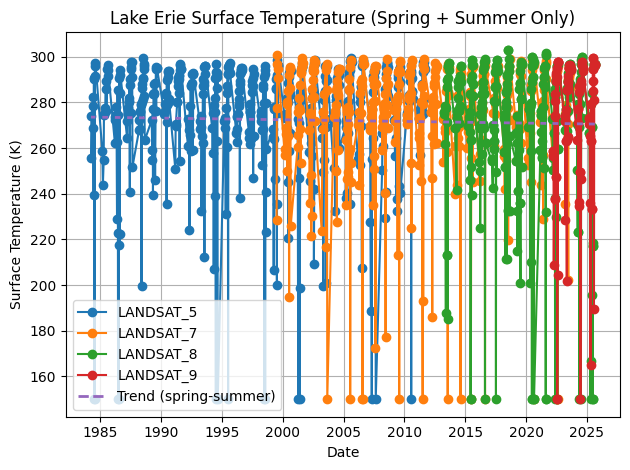

In [367]:
df["month"] = df["date"].dt.month
df_ss = df[df["month"].isin([3, 4, 5, 6, 7, 8])] # March-August, "spring-summer"

# Compute trend across the entire dataset
x = df_ss["date"].map(lambda d: d.toordinal())
y = df_ss["average_surface_temp"]
m, b = np.polyfit(x, y, 1)  
df_ss["trend"] = m * x + b

for sat, group in df_ss.groupby("satellite"):
    plt.plot(group["date"], group["average_surface_temp"], marker='o', linestyle='-', label=sat)

plt.xlabel("Date")
plt.ylabel("Surface Temperature (K)")
plt.title("Lake Erie Surface Temperature (Spring + Summer Only)")

# Plot the trendline 
plt.plot(df["date"], df["trend"], linestyle='--', linewidth=2, label="Trend (spring-summer)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This trendline actually tilts downward. Other graphs indicating Lake Eerie's temperature increase plot surface temperature via month instead of annually, this method of visualization may more strongly convey trends across seasons, and prevent averaging across multiple years/seasons.